In [288]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler


In [289]:
df = pd.read_csv('/users/imbahndu/Desktop/Columbia DBM/Typing dataset/typing.csv', low_memory=False)

In [290]:
df.head()

,Unnamed: 0,UserKey,Date,Timestamp,Hand,HoldTime,Direction,LatencyTime,FlightTime,Filename,...,Parkinsons,Tremors,DiagnosisYear,Sided,UPDRS,Impact,Levadopa,DA,MAOB,Other
0,0,0EA27ICBLF,160722,18:41:04.336,L,0101.6,LL,0234.4,0156.3,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
1,1,0EA27ICBLF,160722,18:42:14.070,L,0085.9,LL,0437.5,0359.4,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
2,2,0EA27ICBLF,160722,18:42:14.273,L,0078.1,LL,0210.9,0125.0,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
3,3,0EA27ICBLF,160722,18:42:14.617,L,0062.5,LL,0359.4,0281.3,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
4,4,0EA27ICBLF,160722,18:42:15.586,S,0125.0,LS,0187.5,0093.8,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False


In [291]:
#Finding out the number of missing values
null_series = df.isnull().sum()

print(null_series)

print(type(null_series))

Unnamed: 0             0
UserKey                0
Date                   0
Timestamp              0
Hand                   0
HoldTime               0
Direction              0
LatencyTime            0
FlightTime             2
Filename               0
BirthYear        2153339
Gender            301987
Parkinsons        301987
Tremors           301987
DiagnosisYear    1469539
Sided            3498254
UPDRS             301987
Impact            480998
Levadopa          301987
DA                301987
MAOB              301987
Other             301987
dtype: int64
<class 'pandas.core.series.Series'>


In [292]:
#Dropping all the rows with couts 301987
rows_to_drop = []
for col in range(len(null_series)):
    if null_series[col] == 301987:
        rows_to_drop.append(col)

columns = [] 
for row in rows_to_drop:
    columns.append(df.columns[row])

print(columns)

df = df.dropna(subset = columns)
print(df)

['Gender', 'Parkinsons', 'Tremors', 'UPDRS', 'Levadopa', 'DA', 'MAOB', 'Other']


/tmp/ipykernel_3551327/2088116909.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if null_series[col] == 301987:


         Unnamed: 0     UserKey    Date     Timestamp Hand HoldTime Direction  \
0                 0  0EA27ICBLF  160722  18:41:04.336    L   0101.6        LL   
1                 1  0EA27ICBLF  160722  18:42:14.070    L   0085.9        LL   
2                 2  0EA27ICBLF  160722  18:42:14.273    L   0078.1        LL   
3                 3  0EA27ICBLF  160722  18:42:14.617    L   0062.5        LL   
4                 4  0EA27ICBLF  160722  18:42:15.586    S   0125.0        LS   
...             ...         ...     ...           ...  ...      ...       ...   
9316853     9316853  ZYWLN4JVLA  170126  13:56:20.117    L   0195.3        RL   
9316854     9316854  ZYWLN4JVLA  170126  13:56:20.242    R   0105.5        LR   
9316855     9316855  ZYWLN4JVLA  170126  13:56:33.625    L   0168.0        LL   
9316856     9316856  ZYWLN4JVLA  170126  13:56:33.836    L   0097.7        LL   
9316857     9316857  ZYWLN4JVLA  170126  13:56:34.066    L   0168.0        LL   

        LatencyTime FlightT

In [293]:
#Verifying if code worked and all rows with 301987
df.isnull().sum()

Unnamed: 0             0
UserKey                0
Date                   0
Timestamp              0
Hand                   0
HoldTime               0
Direction              0
LatencyTime            0
FlightTime             2
Filename               0
BirthYear        1851352
Gender                 0
Parkinsons             0
Tremors                0
DiagnosisYear    1167552
Sided            3196267
UPDRS                  0
Impact            179011
Levadopa               0
DA                     0
MAOB                   0
Other                  0
dtype: int64

In [294]:
#Dropping the unnamed column --> don't see why it's necessary
df.drop(columns = "Unnamed: 0")

,UserKey,Date,Timestamp,Hand,HoldTime,Direction,LatencyTime,FlightTime,Filename,BirthYear,...,Parkinsons,Tremors,DiagnosisYear,Sided,UPDRS,Impact,Levadopa,DA,MAOB,Other
0,0EA27ICBLF,160722,18:41:04.336,L,0101.6,LL,0234.4,0156.3,0EA27ICBLF_1607.txt,1952.0,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
1,0EA27ICBLF,160722,18:42:14.070,L,0085.9,LL,0437.5,0359.4,0EA27ICBLF_1607.txt,1952.0,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
2,0EA27ICBLF,160722,18:42:14.273,L,0078.1,LL,0210.9,0125.0,0EA27ICBLF_1607.txt,1952.0,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
3,0EA27ICBLF,160722,18:42:14.617,L,0062.5,LL,0359.4,0281.3,0EA27ICBLF_1607.txt,1952.0,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
4,0EA27ICBLF,160722,18:42:15.586,S,0125.0,LS,0187.5,0093.8,0EA27ICBLF_1607.txt,1952.0,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9316853,ZYWLN4JVLA,170126,13:56:20.117,L,0195.3,RL,0425.8,261.7,ZYWLN4JVLA_1701.txt,NaN,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
9316854,ZYWLN4JVLA,170126,13:56:20.242,R,0105.5,LR,0214.8,19.5,ZYWLN4JVLA_1701.txt,NaN,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
9316855,ZYWLN4JVLA,170126,13:56:33.625,L,0168.0,LL,0332.0,15.6,ZYWLN4JVLA_1701.txt,NaN,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
9316856,ZYWLN4JVLA,170126,13:56:33.836,L,0097.7,LL,0281.3,113.3,ZYWLN4JVLA_1701.txt,NaN,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True


In [295]:
#Still left with 9M rows, so deleting columns with duplicates userkeys 

df = df.groupby("UserKey").head(1000).reset_index(drop=True)

#df = df.drop_duplicates(subset="UserKey").reset_index(drop=True)

In [296]:
df

,Unnamed: 0,UserKey,Date,Timestamp,Hand,HoldTime,Direction,LatencyTime,FlightTime,Filename,...,Parkinsons,Tremors,DiagnosisYear,Sided,UPDRS,Impact,Levadopa,DA,MAOB,Other
0,0,0EA27ICBLF,160722,18:41:04.336,L,0101.6,LL,0234.4,0156.3,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
1,1,0EA27ICBLF,160722,18:42:14.070,L,0085.9,LL,0437.5,0359.4,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
2,2,0EA27ICBLF,160722,18:42:14.273,L,0078.1,LL,0210.9,0125.0,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
3,3,0EA27ICBLF,160722,18:42:14.617,L,0062.5,LL,0359.4,0281.3,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
4,4,0EA27ICBLF,160722,18:42:15.586,S,0125.0,LS,0187.5,0093.8,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172078,9309199,ZYWLN4JVLA,170121,13:54:20.340,R,0007.8,RR,0089.8,296.9,ZYWLN4JVLA_1701.txt,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
172079,9309200,ZYWLN4JVLA,170121,13:54:20.453,L,0121.1,RL,0089.8,296.9,ZYWLN4JVLA_1701.txt,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
172080,9309201,ZYWLN4JVLA,170121,13:54:20.539,S,0207.0,LS,0089.8,296.9,ZYWLN4JVLA_1701.txt,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
172081,9309202,ZYWLN4JVLA,170121,13:54:26.406,L,0316.4,SL,0675.8,410.2,ZYWLN4JVLA_1701.txt,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True


In [297]:
df["Parkinsons"].value_counts()

#Will balance this during preprocessing 

Parkinsons
True     128686
False     43397
Name: count, dtype: int64

In [298]:
#Checking the URPDS column
df["UPDRS"].value_counts()

UPDRS
Don't know    166065
3               2009
2               2000
4               2000
1                  9
Name: count, dtype: int64

In [299]:
#Dropping columns (both categorical and numerical col) that will not impact a model
df = df.drop(columns = ["BirthYear", "UserKey", "Tremors", "DiagnosisYear", "Sided", "Impact", "UPDRS", "Levadopa", "MAOB", "DA", "Other", "Unnamed: 0", "Date", "Filename", "Timestamp"])


In [300]:
#One hot enconding teh gender
df = pd.get_dummies(df, columns=["Gender"],drop_first=True)

In [301]:
df.head(10)

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,L,0101.6,LL,0234.4,0156.3,True,False
1,L,0085.9,LL,0437.5,0359.4,True,False
2,L,0078.1,LL,0210.9,0125.0,True,False
3,L,0062.5,LL,0359.4,0281.3,True,False
4,S,0125.0,LS,0187.5,0093.8,True,False
5,L,0078.1,SL,0226.6,0101.6,True,False
6,R,0085.9,LR,0195.3,0117.2,True,False
7,R,0085.9,RR,0359.4,0296.9,True,False
8,L,0070.3,RL,0429.7,0343.8,True,False
9,L,0101.6,LL,0406.3,0335.9,True,False


In [302]:
print(df["Hand"].unique())

['L' 'S' 'R' '160912' '170211' '160821' '160909' '11:02:57.906' '160918'
 '160705' '160628' '160807' '160815' '160825' '160830' 'ZWBPPNQCUX']


In [303]:
print(df["Direction"].unique())

['LL' 'LS' 'SL' 'LR' 'RR' 'RL' 'RS' 'SR' 'SS' 'R' '160811' 'KTUVFFSLN4'
 'L' '0109.4' '160906' '160826' 'SYUUDFV8IU' 'LLUJ2F1R6ODJ' 'S'
 'LLZWBPPNQCUX' '13:50:29.812']


In [304]:
#Dropping rows with weird labels for categorical columns, hands and directions
correct_hands = ["L", "R"]

for col in correct_hands:

    df = df[df["Hand"].isin(correct_hands)]

df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,L,0101.6,LL,0234.4,0156.3,True,False
1,L,0085.9,LL,0437.5,0359.4,True,False
2,L,0078.1,LL,0210.9,0125.0,True,False
3,L,0062.5,LL,0359.4,0281.3,True,False
5,L,0078.1,SL,0226.6,0101.6,True,False
...,...,...,...,...,...,...,...
172077,R,0109.4,LR,0144.5,121.1,True,False
172078,R,0007.8,RR,0089.8,296.9,True,False
172079,L,0121.1,RL,0089.8,296.9,True,False
172081,L,0316.4,SL,0675.8,410.2,True,False


In [305]:
#Verifying if I got rid of all weird  numbers
print(df["Hand"].value_counts())

print(df["Hand"].unique())

Hand
L    81304
R    63342
Name: count, dtype: int64
['L' 'R']


In [306]:
#Doing thesame thing for direction 

correct_directions = ["LL","LR" ,"RR", "RL"]

for col in correct_directions:

    df = df[df["Direction"].isin(correct_directions)]

df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,L,0101.6,LL,0234.4,0156.3,True,False
1,L,0085.9,LL,0437.5,0359.4,True,False
2,L,0078.1,LL,0210.9,0125.0,True,False
3,L,0062.5,LL,0359.4,0281.3,True,False
6,R,0085.9,LR,0195.3,0117.2,True,False
...,...,...,...,...,...,...,...
172076,L,0031.3,LL,0144.5,121.1,True,False
172077,R,0109.4,LR,0144.5,121.1,True,False
172078,R,0007.8,RR,0089.8,296.9,True,False
172079,L,0121.1,RL,0089.8,296.9,True,False


 LightBGM modeling-specific Label Encoding Categorical Variables 

In [307]:
#LabelEncoding these values --> For future app, this would be helpful

cat_columns = ["Hand", "Direction"]

from sklearn.preprocessing import LabelEncoder

#Calling the module, fitting for each cat variables

for col in df[cat_columns]:

    label_encoder = LabelEncoder()

    df[col] = label_encoder.fit_transform(df[col])
    
    print(df[col].unique())


[0 1]
[0 1 3 2]


In [308]:
print(df["Hand"].unique())

[0 1]


In [309]:
print(df["Direction"])

0         0
1         0
2         0
3         0
6         1
         ..
172076    0
172077    1
172078    3
172079    2
172082    1
Name: Direction, Length: 127530, dtype: int64


In [310]:
#Printing the types of all columns
print(df.dtypes)


Hand            int64
HoldTime       object
Direction       int64
LatencyTime    object
FlightTime     object
Parkinsons     object
Gender_Male      bool
dtype: object


In [311]:
#Drooping the expected numerical columns to float
expected_numerical = ["HoldTime", "LatencyTime", "FlightTime"]

# Convert columns to numeric, else convert them to NAN
for col in expected_numerical:

    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with NaN in any of the expected numeric columns
df.dropna(subset=expected_numerical, inplace=True)


In [312]:
#Converting the string literal of PD to bool 

df["Parkinsons"] = df["Parkinsons"].astype(bool)

In [313]:
print(df.dtypes)

Hand             int64
HoldTime       float64
Direction        int64
LatencyTime    float64
FlightTime     float64
Parkinsons        bool
Gender_Male       bool
dtype: object


In [314]:
#Viewing all the rows in teh dataset

In [315]:
#Saving df at this stage as for lightbgm

df.to_csv("lightbgm.csv",  index=True)

In [316]:
#One hot encoding catgorical variables

cat_columns =[col for col in df.columns if df[col].dtype == "object"]

#Saving numerical columns just in case
num_columns = [col for col in df.columns if df[col].dtype == "float64" or df[col].dtype == "int64"]

df = pd.get_dummies(df, columns=cat_columns, dtype=float)

In [317]:
num_columns

['Hand', 'HoldTime', 'Direction', 'LatencyTime', 'FlightTime']

In [318]:
df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,0,101.6,0,234.4,156.3,True,False
1,0,85.9,0,437.5,359.4,True,False
2,0,78.1,0,210.9,125.0,True,False
3,0,62.5,0,359.4,281.3,True,False
6,1,85.9,1,195.3,117.2,True,False
...,...,...,...,...,...,...,...
172076,0,31.3,0,144.5,121.1,True,False
172077,1,109.4,1,144.5,121.1,True,False
172078,1,7.8,3,89.8,296.9,True,False
172079,0,121.1,2,89.8,296.9,True,False


In [319]:
num_columns

['Hand', 'HoldTime', 'Direction', 'LatencyTime', 'FlightTime']

In [320]:
#Scaling the numerical columns
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(df[num_columns])

data_scaled = scaler.fit_transform(df[num_columns])

print(scaler.mean_)

[  0.44737028 119.14355058   1.36514982 330.90346683 239.21327212]


In [321]:
#Keeping the preprocessed file another csv to facilate modeling

df.to_csv("modeling.csv", index=False)

In [322]:
#Visualizations 

import numpy as np


In [323]:
df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,0,101.6,0,234.4,156.3,True,False
1,0,85.9,0,437.5,359.4,True,False
2,0,78.1,0,210.9,125.0,True,False
3,0,62.5,0,359.4,281.3,True,False
6,1,85.9,1,195.3,117.2,True,False
...,...,...,...,...,...,...,...
172076,0,31.3,0,144.5,121.1,True,False
172077,1,109.4,1,144.5,121.1,True,False
172078,1,7.8,3,89.8,296.9,True,False
172079,0,121.1,2,89.8,296.9,True,False


In [324]:
#Making sure everything is consistent one more time 

for col in df.columns:

    print(col)

    print()

    print(df[col].unique())


Hand

[0 1]
HoldTime

[1.01600e+02 8.59000e+01 7.81000e+01 6.25000e+01 7.03000e+01 3.91000e+01
 9.38000e+01 4.69000e+01 5.47000e+01 1.09400e+02 1.79700e+02 1.32800e+02
 1.17200e+02 3.13000e+01 1.25000e+02 1.56300e+02 1.87500e+02 2.14800e+02
 6.64000e+01 8.98000e+01 1.13300e+02 8.20000e+01 7.42000e+01 1.21100e+02
 1.28900e+02 9.77000e+01 1.17000e+01 1.71900e+02 1.05500e+02 1.56000e+01
 1.52300e+02 1.48400e+02 1.36700e+02 5.08000e+01 1.60200e+02 1.40600e+02
 1.64100e+02 4.30000e+01 5.86000e+01 1.44500e+02 1.68000e+02 3.52000e+01
 2.34000e+01 1.46500e+02 2.03100e+02 9.18000e+01 1.27000e+02 7.23000e+01
 5.66000e+01 1.11300e+02 6.84000e+01 7.62000e+01 9.57000e+01 6.83600e+02
 2.65600e+02 8.79000e+01 6.05000e+01 3.90000e+00 6.45000e+01 4.49000e+01
 2.34400e+02 9.96000e+01 8.40000e+01 1.15200e+02 2.07000e+02 1.38700e+02
 2.46100e+02 1.03500e+02 2.48000e+02 1.30900e+02 1.58200e+02 1.85500e+02
 2.36300e+02 1.07400e+02 2.71500e+02 1.73800e+02 2.40200e+02 1.42600e+02
 2.55900e+02 1.54300e+02 2.85

In [325]:
park_scaled = df["Parkinsons"]

In [326]:
park_scaled.isna().sum()

0

In [327]:
#Visualizations
import seaborn as sns
import matplotlib.pyplot as plt

Pairplot Visualizations

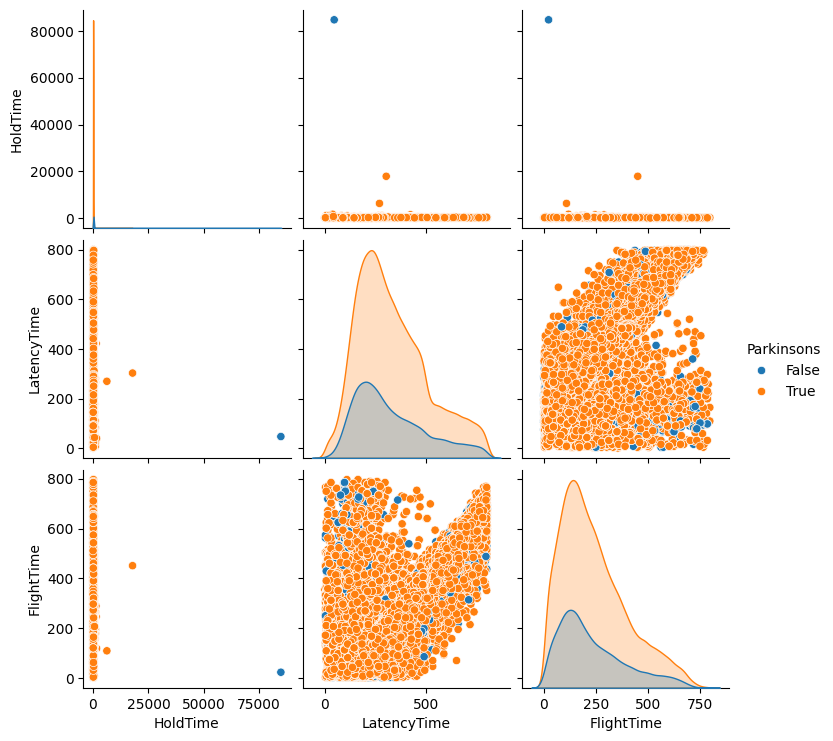

In [328]:
plt_columns = ["HoldTime", "LatencyTime", "FlightTime", "Parkinsons"]
sns.pairplot(df[plt_columns], hue="Parkinsons", diag_kind="kde")
plt.show()

Heatmap Correlations

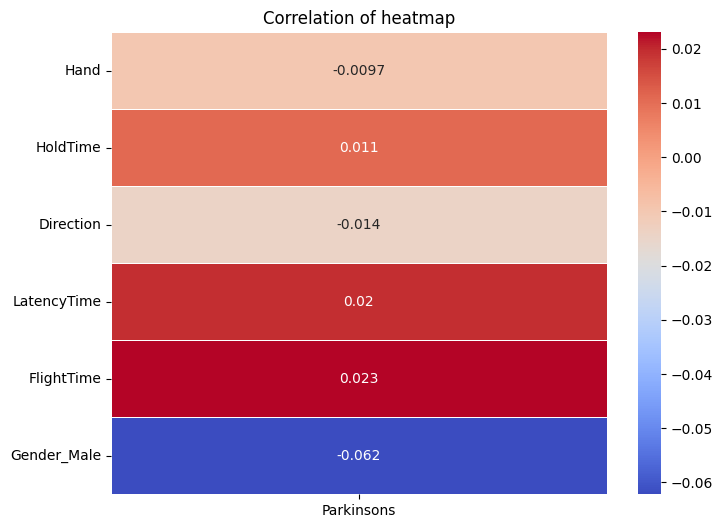

In [329]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr()[["Parkinsons"]].drop(index="Parkinsons"), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation of heatmap")
plt.show()


Histograms plotting for each feature

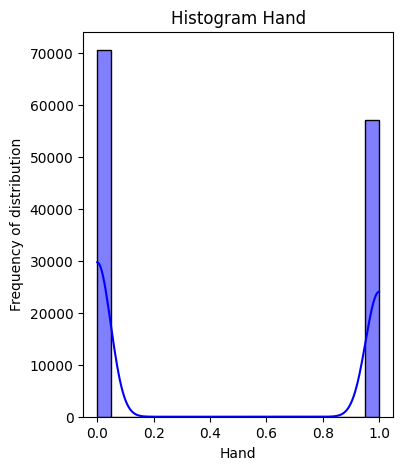

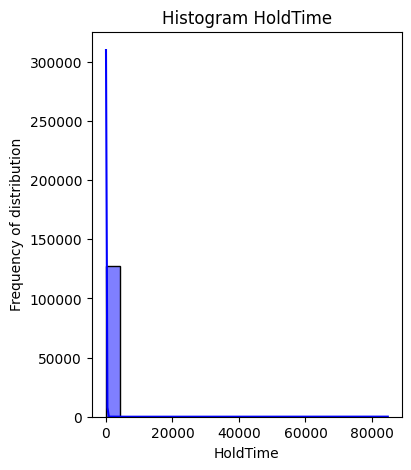

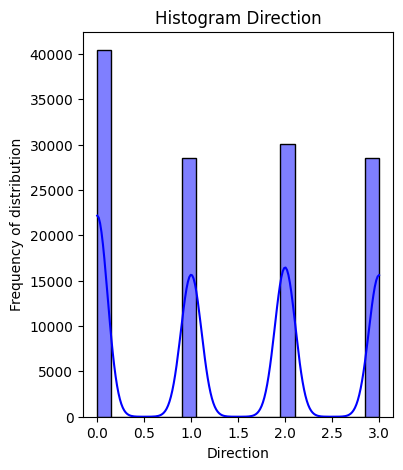

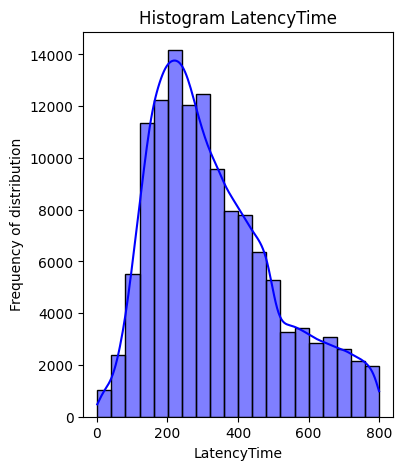

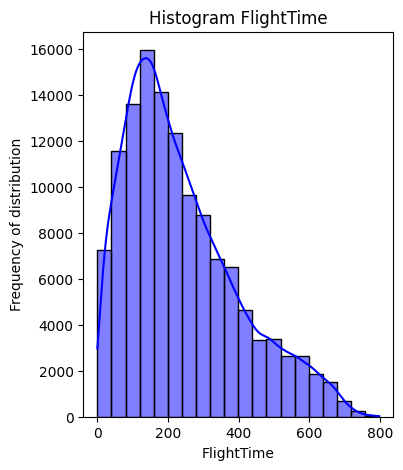

In [330]:
#Looping over num_columns for histogram plot
for col in num_columns:
    
    plt.figure(figsize=(4,5))
    sns.histplot(df[col], bins=20, kde=True, color="blue")
    plt.title("Histogram" + " " + col)
    plt.xlabel(col)
    plt.ylabel("Frequency of distribution")
    plt.show()

Visualizations after preprocessing 

In [331]:
len(num_columns)
print(num_columns)

['Hand', 'HoldTime', 'Direction', 'LatencyTime', 'FlightTime']


In [332]:
#Creating a dataframe with the scaled data and visualizing it again
df_scaled = pd.DataFrame(data=data_scaled, columns=num_columns)

df_scaled

,Hand,HoldTime,Direction,LatencyTime,FlightTime
0,-0.899739,-0.070336,-1.191473,-0.554165,-0.521748
1,-0.899739,-0.133282,-1.191473,0.612123,0.756299
2,-0.899739,-0.164554,-1.191473,-0.689112,-0.718710
3,-0.899739,-0.227098,-1.191473,0.163639,0.264839
4,1.111434,-0.133282,-0.318695,-0.778694,-0.767793
...,...,...,...,...,...
127518,-0.899739,-0.352186,-1.191473,-1.070409,-0.743251
127519,1.111434,-0.039064,-0.318695,-1.070409,-0.743251
127520,1.111434,-0.446404,1.426861,-1.384520,0.363005
127521,-0.899739,0.007844,0.554083,-1.384520,0.363005


Histogram visualizations

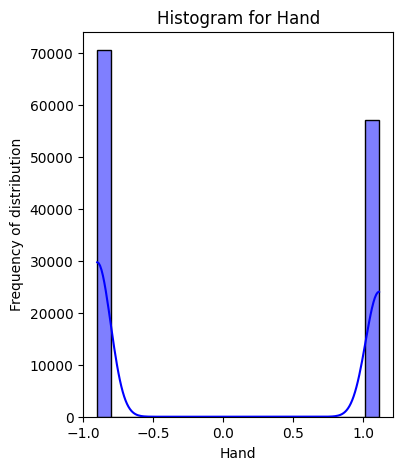

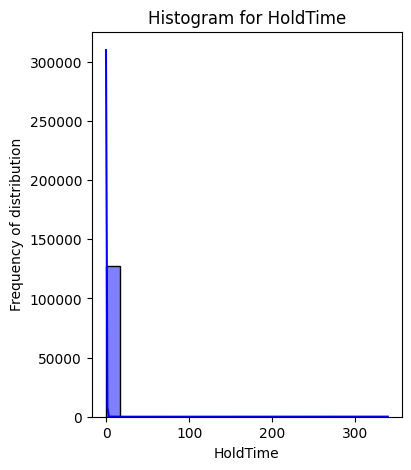

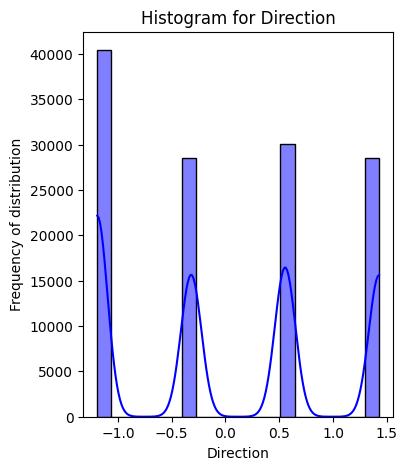

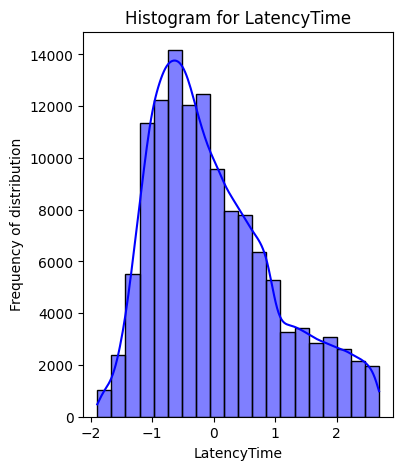

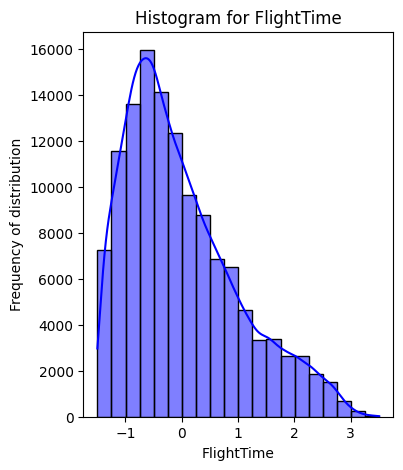

In [333]:
for col in num_columns:
    
    plt.figure(figsize=(4,5))
    sns.histplot(df_scaled[col], bins=20, kde=True, color="blue")
    plt.title("Histogram for" + " " + col)
    plt.xlabel(col)
    plt.ylabel("Frequency of distribution")
    plt.show()

Pairplot visualizations

Heatmap Visualizations

In [334]:
df_scaled["Parkinsons"] = park_scaled.reset_index(drop=True)

In [335]:
df_scaled["Parkinsons"].isna().sum()

0

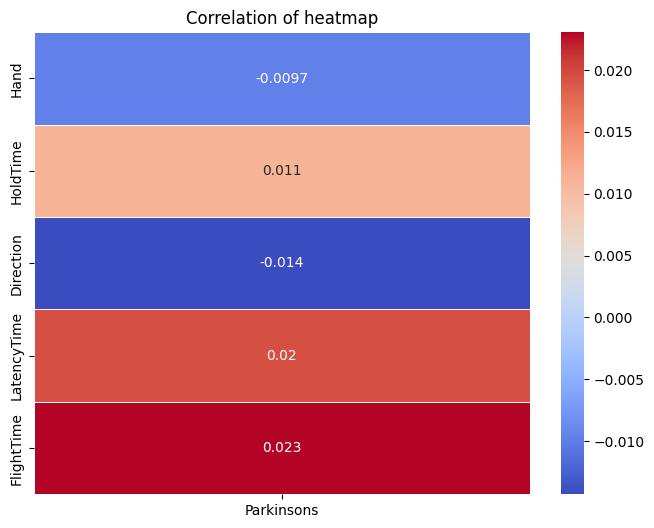

In [336]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_scaled.corr()[["Parkinsons"]].drop(index="Parkinsons"), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation of heatmap")
plt.show()


In [337]:
#Exporting this in the file directory for storage for a neural network

df_scaled.to_csv("nn.csv", index=False)